# Analysis Notebook (All-in-One)
This notebook combines data exploration, preprocessing checks, multimodal pairing, and model sanity checks in small steps.

In [1]:
import os
import sys
print('Step 1: basic imports done')


Step 1: basic imports done


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('Step 2: numpy/pandas/matplotlib imported')

Step 2: numpy/pandas/matplotlib imported


In [3]:
import cv2
import torch
import torchaudio
print('Step 3: cv2/torch/torchaudio imported')

Step 3: cv2/torch/torchaudio imported


In [4]:
import importlib
from pathlib import Path
sys.path.append(os.path.abspath('..'))
from utils import preprocessing
import config
importlib.reload(preprocessing)
importlib.reload(config)
print('Step 4: project modules imported and reloaded')

Step 4: project modules imported and reloaded


## 1) Dataset Paths

In [5]:
BASE = '../data'
AUDIO_DIR = os.path.join(BASE, 'AudioWAV')
VIDEO_DIR = os.path.join(BASE, 'VideoFlash')
print('Step 5: paths set')
print('AUDIO_DIR =', AUDIO_DIR)
print('VIDEO_DIR =', VIDEO_DIR)

Step 5: paths set
AUDIO_DIR = ../data/AudioWAV
VIDEO_DIR = ../data/VideoFlash


In [6]:
print('Step 6: path existence check')
print('Audio exists:', os.path.isdir(AUDIO_DIR))
print('Video exists:', os.path.isdir(VIDEO_DIR))

Step 6: path existence check
Audio exists: True
Video exists: True


## 2) File Discovery

In [7]:
audio_files = sorted([f for f in os.listdir(AUDIO_DIR) if f.endswith('.wav')])
video_files = sorted([f for f in os.listdir(VIDEO_DIR) if f.endswith('.flv') or f.endswith('.mp4')])
print('Step 7: discovered files')
print('Audio count:', len(audio_files))
print('Video count:', len(video_files))

Step 7: discovered files
Audio count: 7442
Video count: 7442


In [8]:
print('Step 8: sample filenames')
print('Audio sample:', audio_files[:3])
print('Video sample:', video_files[:3])

Step 8: sample filenames
Audio sample: ['1001_DFA_ANG_XX.wav', '1001_DFA_DIS_XX.wav', '1001_DFA_FEA_XX.wav']
Video sample: ['1001_DFA_ANG_XX.mp4', '1001_DFA_DIS_XX.mp4', '1001_DFA_FEA_XX.mp4']


## 3) Build Metadata DataFrame

In [9]:
emotion_map = {'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fear', 'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad'}
print('Step 9: emotion map ready')

Step 9: emotion map ready


In [10]:
rows = []
for f in audio_files:
    key = f.replace('.wav', '')
    parts = key.split('_')
    if len(parts) >= 4:
        rows.append({'audio_key': key, 'actor_id': parts[0], 'statement': parts[1], 'emotion_code': parts[2], 'intensity': parts[3], 'emotion': emotion_map.get(parts[2], 'unknown')})
print('Step 10: parsed audio metadata rows =', len(rows))

Step 10: parsed audio metadata rows = 7442


In [11]:
df_audio = pd.DataFrame(rows)
df_audio['audio_path'] = df_audio['audio_key'].apply(lambda k: os.path.join(AUDIO_DIR, f'{k}.wav'))
print('Step 11: df_audio created')
print(df_audio.head(3))

Step 11: df_audio created
         audio_key actor_id statement emotion_code intensity  emotion  \
0  1001_DFA_ANG_XX     1001       DFA          ANG        XX    angry   
1  1001_DFA_DIS_XX     1001       DFA          DIS        XX  disgust   
2  1001_DFA_FEA_XX     1001       DFA          FEA        XX     fear   

                             audio_path  
0  ../data/AudioWAV/1001_DFA_ANG_XX.wav  
1  ../data/AudioWAV/1001_DFA_DIS_XX.wav  
2  ../data/AudioWAV/1001_DFA_FEA_XX.wav  


In [12]:
video_rows = []
for f in video_files:
    k = f.rsplit('.', 1)[0]
    video_rows.append({'audio_key': k, 'video_path': os.path.join(VIDEO_DIR, f)})
df_video = pd.DataFrame(video_rows)
print('Step 12: df_video created with rows =', len(df_video))

Step 12: df_video created with rows = 7442


In [13]:
df_multimodal = pd.merge(df_audio, df_video, on='audio_key', how='inner')
print('Step 13: merged multimodal pairs =', len(df_multimodal))
print(df_multimodal[['audio_key', 'emotion', 'audio_path', 'video_path']].head(3))

Step 13: merged multimodal pairs = 7441
         audio_key  emotion                            audio_path  \
0  1001_DFA_ANG_XX    angry  ../data/AudioWAV/1001_DFA_ANG_XX.wav   
1  1001_DFA_DIS_XX  disgust  ../data/AudioWAV/1001_DFA_DIS_XX.wav   
2  1001_DFA_FEA_XX     fear  ../data/AudioWAV/1001_DFA_FEA_XX.wav   

                               video_path  
0  ../data/VideoFlash/1001_DFA_ANG_XX.mp4  
1  ../data/VideoFlash/1001_DFA_DIS_XX.mp4  
2  ../data/VideoFlash/1001_DFA_FEA_XX.mp4  


## 4) Quick EDA

In [14]:
print('Step 14: emotion counts')
print(df_multimodal['emotion'].value_counts())

Step 14: emotion counts
emotion
angry      1271
disgust    1271
fear       1271
happy      1271
sad        1270
neutral    1087
Name: count, dtype: int64


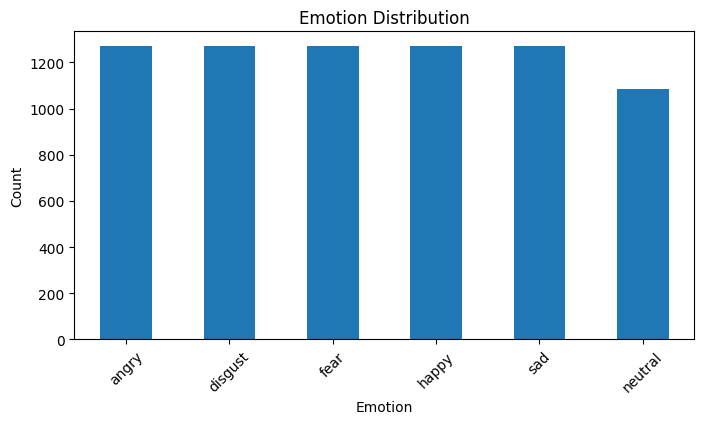

Step 15: emotion bar plot shown


In [15]:
plt.figure(figsize=(8, 4))
df_multimodal['emotion'].value_counts().plot(kind='bar')
plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
print('Step 15: emotion bar plot shown')

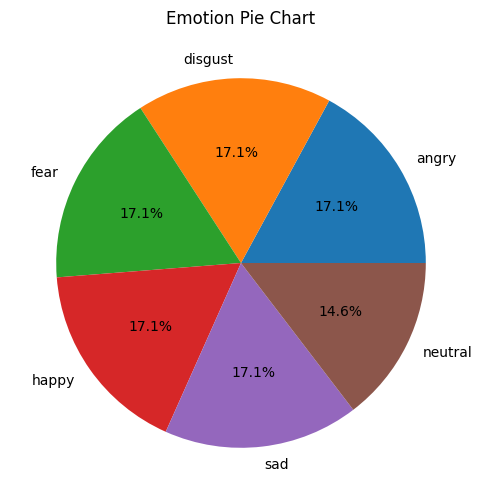

Step 16: emotion pie plot shown


In [16]:
plt.figure(figsize=(6, 6))
df_multimodal['emotion'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Emotion Pie Chart')
plt.show()
print('Step 16: emotion pie plot shown')

## 5) Preprocessing Demo (from previous notebook)

In [17]:
sample_audio = df_multimodal.iloc[0]['audio_path']
sample_video = df_multimodal.iloc[0]['video_path']
print('Step 17: sample files selected')
print(sample_audio)
print(sample_video)

Step 17: sample files selected
../data/AudioWAV/1001_DFA_ANG_XX.wav
../data/VideoFlash/1001_DFA_ANG_XX.mp4


In [18]:
waveform = preprocessing.extract_audio_from_path(sample_audio)
print('Step 18: audio preprocessed')
print('Waveform shape:', tuple(waveform.shape))

Step 18: audio preprocessed
Waveform shape: (1, 80000)


/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(


In [19]:
frames = preprocessing.extract_frames_from_video(sample_video)
print('Step 19: video preprocessed')
print('Frames shape:', frames.shape)

Step 19: video preprocessed
Frames shape: (100, 224, 224, 3)


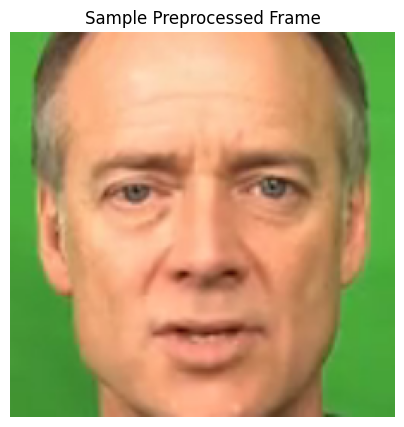

Step 20: sample frame visualized


In [20]:
plt.figure(figsize=(5, 5))
idx = min(10, len(frames) - 1)
plt.imshow(cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Sample Preprocessed Frame')
plt.show()
print('Step 20: sample frame visualized')

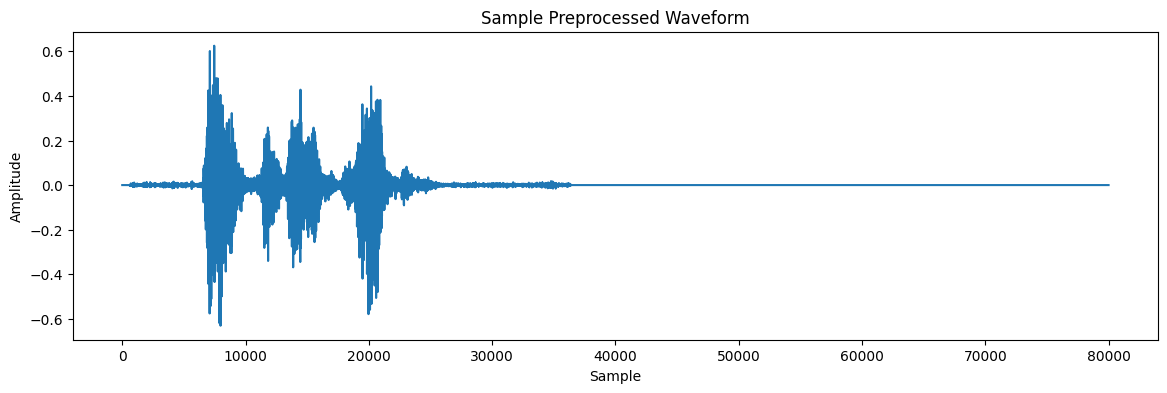

Step 21: waveform visualized


In [21]:
plt.figure(figsize=(14, 4))
plt.plot(waveform.squeeze(0).numpy())
plt.title('Sample Preprocessed Waveform')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.show()
print('Step 21: waveform visualized')

## 6) Model Sanity Check (from previous model debug notebook)

In [22]:
from models.fusion_model import AudioVisualFusionModel
print('Step 22: model class imported')

/Users/kunalpunia/Capstone Project New/project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Step 22: model class imported


In [23]:
device = torch.device(config.DEVICE)
model = AudioVisualFusionModel(device=device).eval()
print('Step 23: model initialized on', device)

Loading weights: 100%|██████████| 422/422 [00:00<00:00, 63671.22it/s]
HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 447/447 [00:00<00:00, 7765.94it/s]
SwinModel LOAD REPORT from: microsoft/swin-base-patch4-window7-224-in22k
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step 23: model initialized on cpu


In [24]:
dummy_audio = torch.zeros(2, 1, config.MAX_AUDIO_LEN, device=device)
dummy_video = torch.zeros(2, config.MAX_FRAMES, config.IMAGE_SIZE, config.IMAGE_SIZE, 3, device=device)
print('Step 24: dummy tensors created')
print('dummy_audio:', tuple(dummy_audio.shape))
print('dummy_video:', tuple(dummy_video.shape))

Step 24: dummy tensors created
dummy_audio: (2, 1, 80000)
dummy_video: (2, 100, 224, 224, 3)


In [25]:
with torch.no_grad():
    logits = model(dummy_audio, dummy_video)
print('Step 25: forward pass done')
print('Logits shape:', tuple(logits.shape))

Step 25: forward pass done
Logits shape: (2, 6)


## Next (Notebook-Only Training Flow)
You have already completed:
- data path checks
- audio/video pairing
- EDA
- preprocessing sanity checks
- model import sanity

Now continue in this same notebook with a small train/validation workflow.

## 7) In-notebook train/validation setup

In [26]:
from torch.utils.data import DataLoader, Subset
from torch import nn
from torch.optim import AdamW
import random

from utils.dataset import AudioVisualDataset
from models.fusion_model import AudioVisualFusionModel

print('Step 26: training utilities imported')

Step 26: training utilities imported


In [27]:
from pathlib import Path

candidate_paths = [
    config.CREMA_D_PATH,
    '../data',
    'data',
]

resolved_data_path = None
for p in candidate_paths:
    if os.path.isdir(os.path.join(p, 'AudioWAV')) and os.path.isdir(os.path.join(p, 'VideoFlash')):
        resolved_data_path = p
        break

if resolved_data_path is None:
    here = Path.cwd()
    raise FileNotFoundError(
        f'Could not find dataset folders from cwd={here}. Tried: {candidate_paths}'
    )

config.CREMA_D_PATH = resolved_data_path
full_dataset = AudioVisualDataset(data_path=config.CREMA_D_PATH, modality_dropout_rate=0.0)
n_total = len(full_dataset)

indices = list(range(n_total))
random.seed(42)
random.shuffle(indices)

split = int(0.8 * n_total)
train_idx = indices[:split]
val_idx = indices[split:]

train_ds = Subset(full_dataset, train_idx)
val_ds = Subset(full_dataset, val_idx)

print('Step 27: dataset split ready')
print('Using data path:', config.CREMA_D_PATH)
print('Total:', n_total, 'Train:', len(train_ds), 'Val:', len(val_ds))

Step 27: dataset split ready
Using data path: ../data
Total: 7441 Train: 5952 Val: 1489


In [28]:
# train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

print('Step 28: dataloaders created')
print('Train batches:', len(train_loader), 'Val batches:', len(val_loader))

Step 28: dataloaders created
Train batches: 5952 Val batches: 1489


In [29]:
device = torch.device(config.DEVICE)
model = AudioVisualFusionModel(device=device).to(device)

# Train only fusion layers (encoders are frozen)
trainable_params = list(model.trainable_parameters())
optimizer = AdamW(trainable_params, lr=1e-4, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()

total_params = sum(p.numel() for p in model.parameters())
trainable_param_count = sum(p.numel() for p in trainable_params)
print('Step 29: model/optimizer/loss initialized on', device)
print('Total params:', f'{total_params:,}')
print('Trainable params (fusion only):', f'{trainable_param_count:,}')

Loading weights: 100%|██████████| 422/422 [00:00<00:00, 81717.28it/s]
HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 447/447 [00:00<00:00, 11533.16it/s]
SwinModel LOAD REPORT from: microsoft/swin-base-patch4-window7-224-in22k
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step 29: model/optimizer/loss initialized on cpu
Total params: 443,256,126
Trainable params (fusion only): 38,974,982


In [30]:
batch = next(iter(train_loader))
audio = batch['audio'].to(device)
video = batch['video'].to(device)
labels = batch['label'].to(device)

#just added here for memory safety during analysis
video = video[:, :4]  # reduce frames

optimizer.zero_grad()
logits = model(audio, video)
loss = criterion(logits, labels)
loss.backward()
optimizer.step()

print('Step 30: one training step completed')
print('Loss:', float(loss.item()), 'Logits shape:', tuple(logits.shape))

/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(


Step 30: one training step completed
Loss: 0.7157657742500305 Logits shape: (1, 6)


In [31]:
model.eval()
val_losses = []

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        if i >= 10:
            break
        audio = batch['audio'].to(device)
        video = batch['video'].to(device)
        labels = batch['label'].to(device)
        logits = model(audio, video)
        val_losses.append(float(criterion(logits, labels).item()))

print('Step 31: validation preview done (first 10 batches max)')
print('Mean val loss:', float(np.mean(val_losses)) if val_losses else 'N/A')

Step 31: validation preview done (first 10 batches max)
Mean val loss: 0.5832827746868133


In [32]:
save_path = '../trained_models/notebook_quick_model.pth'
os.makedirs('../trained_models', exist_ok=True)
torch.save(model.state_dict(), save_path)

print('Step 32: checkpoint saved')
print('Saved to:', save_path)

Step 32: checkpoint saved
Saved to: ../trained_models/notebook_quick_model.pth


## 8) Full notebook pipeline additions (sample-sized)
This section adds all requested items in a lightweight way:
- full-epoch training loops (5/10/20) on a small sampled subset
- per-class metrics + confusion matrix
- modality-ablation checks (audio-missing/video-missing)
- train/val split CSV export for reproducibility

### 8.1 Setup for extended experiments

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import copy

print('Step 33: metrics imports ready (including macro/micro F1)')

Step 33: metrics imports ready (including macro/micro F1)


In [34]:
# Export reproducible split CSVs
artifacts_dir = Path('../artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

def _build_split_df(ds, idx_list, split_name):
    rows = []
    for i in idx_list:
        pair = ds.file_list[i]
        fname = os.path.basename(pair['audio'])
        label = preprocessing.get_label_from_filename(fname)
        rows.append({
            'split': split_name,
            'audio_path': pair['audio'],
            'video_path': pair['video'],
            'label': label,
        })
    return pd.DataFrame(rows)

train_split_df = _build_split_df(full_dataset, train_idx, 'train')
val_split_df = _build_split_df(full_dataset, val_idx, 'val')

train_csv = artifacts_dir / 'train_split.csv'
val_csv = artifacts_dir / 'val_split.csv'
train_split_df.to_csv(train_csv, index=False)
val_split_df.to_csv(val_csv, index=False)

print('Step 34: split CSVs exported')
print('Train CSV:', train_csv, 'rows =', len(train_split_df))
print('Val CSV:', val_csv, 'rows =', len(val_split_df))

Step 34: split CSVs exported
Train CSV: ../artifacts/train_split.csv rows = 5952
Val CSV: ../artifacts/val_split.csv rows = 1489


### 8.2 Sample-sized training loaders (fast)

In [35]:
# MAX_TRAIN_SAMPLES = min(128, len(train_idx))
# MAX_VAL_SAMPLES = min(64, len(val_idx))
MAX_TRAIN_SAMPLES = min(32, len(train_idx))
MAX_VAL_SAMPLES = min(16, len(val_idx))
train_idx_small = train_idx[:MAX_TRAIN_SAMPLES]
val_idx_small = val_idx[:MAX_VAL_SAMPLES]

train_small = Subset(full_dataset, train_idx_small)
val_small = Subset(full_dataset, val_idx_small)

# train_loader_small = DataLoader(train_small, batch_size=4, shuffle=True, num_workers=0)
# val_loader_small = DataLoader(val_small, batch_size=4, shuffle=False, num_workers=0)
train_loader_small = DataLoader(train_small, batch_size=1, shuffle=True, num_workers=0)
val_loader_small = DataLoader(val_small, batch_size=1, shuffle=False, num_workers=0)
print('Step 35: sampled loaders ready')
print('Train samples:', len(train_small), 'Val samples:', len(val_small))
print('Train batches:', len(train_loader_small), 'Val batches:', len(val_loader_small))

Step 35: sampled loaders ready
Train samples: 32 Val samples: 16
Train batches: 32 Val batches: 16


### 8.3 Full-epoch training loops (5/10/20) on sample data

In [36]:
label_names = [k for k, _ in sorted(config.EMOTION_MAP.items(), key=lambda x: x[1])]

def _maybe_drop_modality(audio, video, mode='none'):
    if mode == 'audio_missing':
        audio = torch.zeros_like(audio)
    elif mode == 'video_missing':
        video = torch.zeros_like(video)
    return audio, video

def run_epoch(model, loader, optimizer=None, mode='none', max_batches=None):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    losses = []
    y_true = []
    y_pred = []

    for b_idx, batch in enumerate(loader):
        if max_batches is not None and b_idx >= max_batches:
            break

        audio = batch['audio'].to(device)
        video = batch['video'].to(device)
        labels = batch['label'].to(device)

        #just added here for memory safety during analysis
        video = video[:, :4]  # reduce frames for memory safety

        audio, video = _maybe_drop_modality(audio, video, mode=mode)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(audio, video)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        losses.append(float(loss.item()))
        y_true.extend(torch.argmax(labels, dim=1).detach().cpu().tolist())
        y_pred.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())

    mean_loss = float(np.mean(losses)) if losses else float('nan')
    acc = float(accuracy_score(y_true, y_pred)) if y_true else 0.0
    return mean_loss, acc, y_true, y_pred

print('Step 36: training/evaluation helpers ready')
print('Class order:', label_names)

Step 36: training/evaluation helpers ready
Class order: ['angry', 'happy', 'sad', 'neutral', 'fear', 'disgust']


In [37]:
# EPOCH_OPTIONS = [5, 10, 20]
# MAX_TRAIN_BATCHES_PER_EPOCH = 5
# MAX_VAL_BATCHES = 5

EPOCH_OPTIONS = [1, 3, 5]
MAX_TRAIN_BATCHES_PER_EPOCH = 2
MAX_VAL_BATCHES = 2

experiment_results = {}
best_state = None
best_val_acc = -1.0
best_tag = None

for n_epochs in EPOCH_OPTIONS:
    exp_tag = f'sample_{n_epochs}ep'
    model = AudioVisualFusionModel(device=device).to(device)
    trainable_params = list(model.trainable_parameters())
    optimizer = AdamW(trainable_params, lr=1e-4, weight_decay=1e-5)

    print(f'--- Step 37: starting {exp_tag} ---')
    print('Trainable params in this run:', sum(p.numel() for p in trainable_params))
    history = []

    for ep in range(1, n_epochs + 1):
        tr_loss, tr_acc, _, _ = run_epoch(
            model, train_loader_small, optimizer=optimizer, mode='none', max_batches=MAX_TRAIN_BATCHES_PER_EPOCH
        )
        va_loss, va_acc, _, _ = run_epoch(
            model, val_loader_small, optimizer=None, mode='none', max_batches=MAX_VAL_BATCHES
        )
        history.append({'epoch': ep, 'train_loss': tr_loss, 'train_acc': tr_acc, 'val_loss': va_loss, 'val_acc': va_acc})
        print(f'{exp_tag} | epoch {ep:02d}/{n_epochs} | train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | val_loss={va_loss:.4f} val_acc={va_acc:.3f}')

    experiment_results[exp_tag] = {'history': history, 'model': model}
    final_val_acc = history[-1]['val_acc'] if history else 0.0
    if final_val_acc > best_val_acc:
        best_val_acc = final_val_acc
        best_state = copy.deepcopy(model.state_dict())
        best_tag = exp_tag

print('Step 37 complete: all epoch options finished')
print('Best run:', best_tag, 'val_acc=', best_val_acc)

Loading weights: 100%|██████████| 422/422 [00:00<00:00, 52363.66it/s]
HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 447/447 [00:00<00:00, 16563.63it/s]
SwinModel LOAD REPORT from: microsoft/swin-base-patch4-window7-224-in22k
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please inst

--- Step 37: starting sample_1ep ---
Trainable params in this run: 38974982


/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(


sample_1ep | epoch 01/1 | train_loss=0.6905 train_acc=0.500 | val_loss=0.6246 val_acc=0.000


Loading weights: 100%|██████████| 422/422 [00:00<00:00, 71064.21it/s]
HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 447/447 [00:00<00:00, 16422.32it/s]
SwinModel LOAD REPORT from: microsoft/swin-base-patch4-window7-224-in22k
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please inst

...

sample_5ep | epoch 03/5 | train_loss=0.5844 train_acc=0.000 | val_loss=0.5011 val_acc=0.000


/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(
/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(


sample_5ep | epoch 04/5 | train_loss=0.4668 train_acc=0.500 | val_loss=0.5312 val_acc=0.000


/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(
/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(


sample_5ep | epoch 05/5 | train_loss=0.5485 train_acc=0.000 | val_loss=0.5349 val_acc=0.000
Step 37 complete: all epoch options finished
Best run: sample_1ep val_acc= 0.0


### 8.4 Per-class metrics and confusion matrix (best run)

Loading weights: 100%|██████████| 422/422 [00:00<00:00, 54501.67it/s]
HubertModel LOAD REPORT from: facebook/hubert-large-ls960-ft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 447/447 [00:00<00:00, 13508.57it/s]
SwinModel LOAD REPORT from: microsoft/swin-base-patch4-window7-224-in22k
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please inst

Step 38: baseline evaluation on sampled val set
Baseline accuracy: 0.3125
              precision    recall  f1-score   support

       angry       0.31      1.00      0.48         5
       happy       0.00      0.00      0.00         2
         sad       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00         2
        fear       0.00      0.00      0.00         1
     disgust       0.00      0.00      0.00         4

    accuracy                           0.31        16
   macro avg       0.05      0.17      0.08        16
weighted avg       0.10      0.31      0.15        16



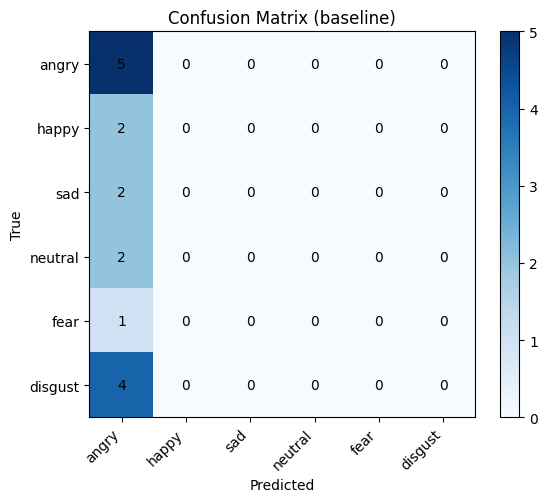

In [38]:
best_model = AudioVisualFusionModel(device=device).to(device)
best_model.load_state_dict(best_state)
best_model.eval()

_, base_acc, y_true, y_pred = run_epoch(
    best_model, val_loader_small, optimizer=None, mode='none', max_batches=None
)

print('Step 38: baseline evaluation on sampled val set')
print('Baseline accuracy:', base_acc)
print(classification_report(y_true, y_pred, labels=list(range(len(label_names))), target_names=label_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix (baseline)')
plt.colorbar()
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45, ha='right')
plt.yticks(tick_marks, label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()

### 8.5 Modality ablation experiments (audio-missing/video-missing)

/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(


Step 39: mode=none accuracy=0.3125


/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(


Step 39: mode=audio_missing accuracy=0.3125


/Users/kunalpunia/Capstone Project New/project/utils/preprocessing.py:135: RuntimeWarning: torchaudio.load failed, trying fallbacks. Error: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.
  warnings.warn(


Step 39: mode=video_missing accuracy=0.3125
            mode  accuracy
0           none    0.3125
1  audio_missing    0.3125
2  video_missing    0.3125


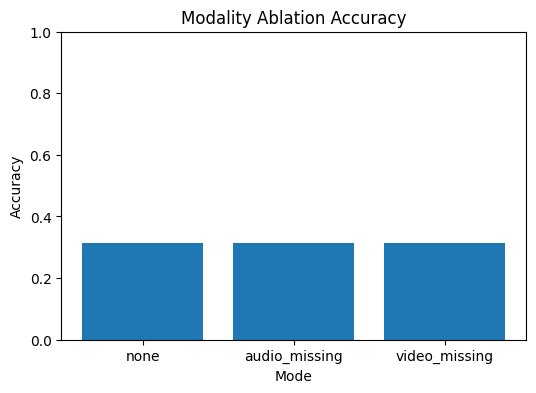

In [39]:
ablation_summary = []
for mode in ['none', 'audio_missing', 'video_missing']:
    _, acc, y_t, y_p = run_epoch(
        best_model, val_loader_small, optimizer=None, mode=mode, max_batches=None
    )
    ablation_summary.append({'mode': mode, 'accuracy': acc})
    print(f'Step 39: mode={mode} accuracy={acc:.4f}')

ablation_df = pd.DataFrame(ablation_summary)
print(ablation_df)

plt.figure(figsize=(6, 4))
plt.bar(ablation_df['mode'], ablation_df['accuracy'])
plt.title('Modality Ablation Accuracy')
plt.xlabel('Mode')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

In [40]:
# Save best sample-run checkpoint and logs (and keep everything visible in notebook)
run_dir = artifacts_dir / 'sample_training'
run_dir.mkdir(parents=True, exist_ok=True)

best_ckpt = run_dir / 'best_sample_model.pth'
torch.save(best_state, best_ckpt)

history_rows = []
for exp_tag, payload in experiment_results.items():
    for row in payload['history']:
        history_rows.append({'experiment': exp_tag, **row})

history_df = pd.DataFrame(history_rows)
history_csv = run_dir / 'epoch_history.csv'
ablation_csv = run_dir / 'ablation_summary.csv'
history_df.to_csv(history_csv, index=False)
ablation_df.to_csv(ablation_csv, index=False)

print('Step 40: artifacts saved and in-memory results ready')
print('Checkpoint:', best_ckpt)
print('History CSV:', history_csv, 'rows =', len(history_df))
print('Ablation CSV:', ablation_csv)
print('Current baseline accuracy:', base_acc)

Step 40: artifacts saved and in-memory results ready
Checkpoint: ../artifacts/sample_training/best_sample_model.pth
History CSV: ../artifacts/sample_training/epoch_history.csv rows = 9
Ablation CSV: ../artifacts/sample_training/ablation_summary.csv
Current baseline accuracy: 0.3125


In [41]:
# Step 41: show experiment summary table directly in notebook
final_rows = []
for exp_tag, payload in experiment_results.items():
    if payload['history']:
        last = payload['history'][-1]
        final_rows.append({
            'experiment': exp_tag,
            'epochs': last['epoch'],
            'final_train_loss': last['train_loss'],
            'final_train_acc': last['train_acc'],
            'final_val_loss': last['val_loss'],
            'final_val_acc': last['val_acc'],
        })

summary_df = pd.DataFrame(final_rows).sort_values('final_val_acc', ascending=False).reset_index(drop=True)
print('Step 41: experiment summary')
print(summary_df)
print('Best experiment from training loop:', best_tag)

Step 41: experiment summary
   experiment  epochs  final_train_loss  final_train_acc  final_val_loss  \
0  sample_1ep       1          0.690482              0.5        0.624568   
1  sample_3ep       3          0.381694              0.5        0.661242   
2  sample_5ep       5          0.548523              0.0        0.534949   

   final_val_acc  
0            0.0  
1            0.0  
2            0.0  
Best experiment from training loop: sample_1ep


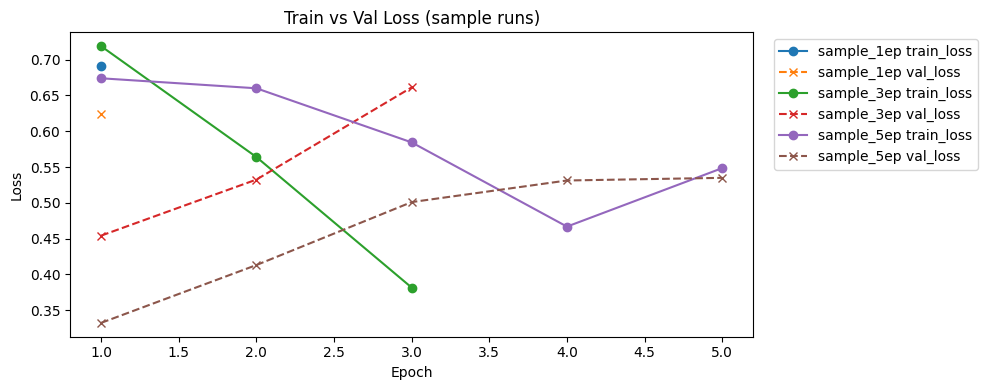

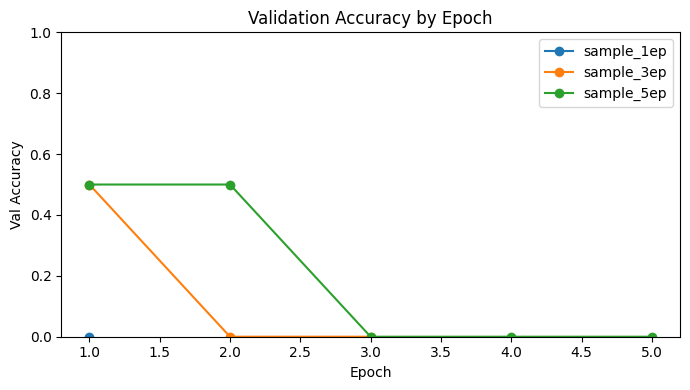

Step 42: training curves shown


In [42]:
# Step 42: plot losses and validation accuracy directly in notebook
plt.figure(figsize=(10, 4))
for exp_tag in history_df['experiment'].unique():
    d = history_df[history_df['experiment'] == exp_tag]
    plt.plot(d['epoch'], d['train_loss'], marker='o', label=f'{exp_tag} train_loss')
    plt.plot(d['epoch'], d['val_loss'], marker='x', linestyle='--', label=f'{exp_tag} val_loss')
plt.title('Train vs Val Loss (sample runs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for exp_tag in history_df['experiment'].unique():
    d = history_df[history_df['experiment'] == exp_tag]
    plt.plot(d['epoch'], d['val_acc'], marker='o', label=exp_tag)
plt.title('Validation Accuracy by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

print('Step 42: training curves shown')

In [43]:
# Step 43: show split preview and ablation table directly in notebook
print('Train split preview:')
print(train_split_df.head(5))
print('Val split preview:')
print(val_split_df.head(5))

print('\nAblation results:')
print(ablation_df)

best_ablation_mode = ablation_df.sort_values('accuracy', ascending=False).iloc[0]['mode']
best_ablation_acc = float(ablation_df.sort_values('accuracy', ascending=False).iloc[0]['accuracy'])
print('Best ablation mode:', best_ablation_mode, 'Accuracy:', best_ablation_acc)

Train split preview:
   split                            audio_path  \
0  train  ../data/AudioWAV/1041_ITS_NEU_XX.wav   
1  train  ../data/AudioWAV/1038_IEO_DIS_MD.wav   
2  train  ../data/AudioWAV/1040_DFA_HAP_XX.wav   
3  train  ../data/AudioWAV/1031_ITH_NEU_XX.wav   
4  train  ../data/AudioWAV/1070_IEO_FEA_LO.wav   

                               video_path label  
0  ../data/VideoFlash/1041_ITS_NEU_XX.mp4   NEU  
1  ../data/VideoFlash/1038_IEO_DIS_MD.mp4   DIS  
2  ../data/VideoFlash/1040_DFA_HAP_XX.mp4   HAP  
3  ../data/VideoFlash/1031_ITH_NEU_XX.mp4   NEU  
4  ../data/VideoFlash/1070_IEO_FEA_LO.mp4   FEA  
Val split preview:
  split                            audio_path  \
0   val  ../data/AudioWAV/1090_TIE_DIS_XX.wav   
1   val  ../data/AudioWAV/1019_DFA_FEA_XX.wav   
2   val  ../data/AudioWAV/1064_DFA_HAP_XX.wav   
3   val  ../data/AudioWAV/1052_TAI_HAP_XX.wav   
4   val  ../data/AudioWAV/1004_TIE_SAD_XX.wav   

                               video_path label  
0  ../data/Vid

In [44]:
# Step 44: per-class metrics table + macro/micro F1
report_dict = classification_report(
    y_true, y_pred,
    labels=list(range(len(label_names))),
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T

macro_f1 = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
micro_f1 = float(f1_score(y_true, y_pred, average='micro', zero_division=0))

print('Step 44: per-class report table')
print(report_df.round(4))
print('Macro F1:', round(macro_f1, 4))
print('Micro F1:', round(micro_f1, 4))

f1_df = pd.DataFrame([
    {'metric': 'Macro F1', 'value': macro_f1},
    {'metric': 'Micro F1', 'value': micro_f1},
])
print('\nF1 Summary:')
print(f1_df.round(4))

Step 44: per-class report table
              precision  recall  f1-score  support
angry            0.3125  1.0000    0.4762   5.0000
happy            0.0000  0.0000    0.0000   2.0000
sad              0.0000  0.0000    0.0000   2.0000
neutral          0.0000  0.0000    0.0000   2.0000
fear             0.0000  0.0000    0.0000   1.0000
disgust          0.0000  0.0000    0.0000   4.0000
accuracy         0.3125  0.3125    0.3125   0.3125
macro avg        0.0521  0.1667    0.0794  16.0000
weighted avg     0.0977  0.3125    0.1488  16.0000
Macro F1: 0.0794
Micro F1: 0.3125

F1 Summary:
     metric   value
0  Macro F1  0.0794
1  Micro F1  0.3125
